In [1]:
import importlib.util
import importlib
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [2]:
import sys
from pathlib import Path

for _candidate in [Path.cwd().resolve(), Path.cwd().resolve().parent, Path.cwd().resolve() / 'Voxelmorph']:
    if (_candidate / 'tuco_dataset.py').exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break
else:
    raise FileNotFoundError('Could not find tuco_dataset.py from the current working directory')

from tuco_dataset import TucoDataset

DOWNSAMPLE = True
DATA_ROOT = '../../Data/Tuco'
MAX_TRAIN = 100
MAX_VAL = None
WINDOW_RADIUS = 3
N_STACK = 8

def _load_volumes(split, max_n):
    ds = TucoDataset(DATA_ROOT, split=split)
    if max_n is not None:
        from torch.utils.data import Subset
        ds = Subset(ds, range(min(max_n, len(ds))))
    mr_list, ct_list, mr_seg_list, ct_seg_list = [], [], [], []
    for sample in ds:
        mr_list.append(sample['moving'].squeeze(0).numpy().astype(np.float32))
        ct_list.append(sample['fixed'].squeeze(0).numpy().astype(np.float32))
        mr_seg_list.append(sample['moving_seg'].squeeze(0).numpy().astype(np.int16))
        ct_seg_list.append(sample['fixed_seg'].squeeze(0).numpy().astype(np.int16))
    return mr_list, ct_list, mr_seg_list, ct_seg_list

print('Loading train volumes...')
train_mr_vols, train_ct_vols, train_mr_segs, train_ct_segs = _load_volumes('train', MAX_TRAIN)
print('Loading val volumes...')
val_mr_vols, val_ct_vols, val_mr_segs, val_ct_segs = _load_volumes('val', MAX_VAL)

if DOWNSAMPLE:
    ORIENT_CONFIG = [
        (0, 96,  'axial',    (112, 96)),
        (1, 112, 'coronal',  (96,  96)),
        (2, 96,  'sagittal', (96,  112)),
    ]
else:
    ORIENT_CONFIG = [
        (0, 176, 'axial',    (208, 192)),
        (1, 208, 'coronal',  (176, 192)),
        (2, 192, 'sagittal', (176, 208)),
    ]

SEG_LABELS = [2, 3, 4, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28]
N_LABELS = len(SEG_LABELS)

n_train = len(train_mr_vols)
stacks_per_subj = sum(d - 2*WINDOW_RADIUS for _, d, _, _ in ORIENT_CONFIG)
print(f'Train: {n_train} subjects x {stacks_per_subj} stacks/subj = {n_train * stacks_per_subj} total')
print(f'Val: {len(val_mr_vols)} subjects')
print(f'{N_LABELS} anatomical labels')


Loading train volumes...
Found 144 volume pairs for split 'train'
Loading val volumes...
Found 18 volume pairs for split 'val'
Train: 100 subjects x 286 stacks/subj = 28600 total
Val: 18 subjects
16 anatomical labels


In [3]:
def multi_orient_generator(mr_vols, ct_vols, mr_segs, ct_segs,
                           batch_size=8, window_radius=WINDOW_RADIUS, rng=None):
    n_subj = len(mr_vols)
    wr = window_radius
    rng = rng if rng is not None else np.random

    def _randint(low, high=None, size=None):
        if hasattr(rng, 'integers'):
            return rng.integers(low, high, size=size)
        return rng.randint(low, high, size=size)

    def _extract_slice(vol, axis, z):
        if axis == 0:
            return vol[z]
        if axis == 1:
            return vol[:, z, :]
        return vol[:, :, z]

    def _extract_stack(vol, axis, z):
        if axis == 0:
            return vol[z-wr : z+wr+1]
        if axis == 1:
            return vol[:, z-wr : z+wr+1, :].transpose(1, 0, 2)
        return vol[:, :, z-wr : z+wr+1].transpose(2, 0, 1)

    while True:
        orient_idx = int(_randint(0, len(ORIENT_CONFIG)))
        axis, D, _, _ = ORIENT_CONFIG[orient_idx]

        mr_subj_idx = np.asarray(_randint(0, n_subj, size=batch_size), dtype=np.int64)
        ct_subj_idx = np.asarray(_randint(0, n_subj, size=batch_size), dtype=np.int64)
        for k in range(batch_size):
            while ct_subj_idx[k] == mr_subj_idx[k]:
                ct_subj_idx[k] = int(_randint(0, n_subj))

        z_idx = np.asarray(_randint(wr, D - wr, size=batch_size), dtype=np.int64)

        mr_batch, ct_batch = [], []
        mr_seg_batch, ct_seg_batch = [], []
        for sm, sc, z in zip(mr_subj_idx, ct_subj_idx, z_idx):
            mr = np.ascontiguousarray(_extract_stack(mr_vols[int(sm)], axis, int(z)))
            ct = np.ascontiguousarray(_extract_stack(ct_vols[int(sc)], axis, int(z)))
            if mr.shape[0] == 7:
                mr = np.concatenate([mr, mr[-1:]], axis=0)
            if ct.shape[0] == 7:
                ct = np.concatenate([ct, ct[-1:]], axis=0)

            mr_batch.append(mr)
            ct_batch.append(ct)
            mr_seg_batch.append(_extract_slice(mr_segs[int(sm)], axis, int(z)))
            ct_seg_batch.append(_extract_slice(ct_segs[int(sc)], axis, int(z)))

        mr_stack = np.stack(mr_batch).astype(np.float32)
        ct_stack = np.stack(ct_batch).astype(np.float32)
        mr_seg = np.stack(mr_seg_batch).astype(np.int64)
        ct_seg = np.stack(ct_seg_batch).astype(np.int64)
        yield mr_stack, ct_stack, mr_seg, ct_seg

# Test generator
test_gen = multi_orient_generator(train_mr_vols, train_ct_vols,
                                  train_mr_segs, train_ct_segs, batch_size=2)
mr, ct, mrs, cts = next(test_gen)
print(f"Batch shapes: mr={mr.shape}, ct={ct.shape}, mr_seg={mrs.shape}, ct_seg={cts.shape}")
del test_gen, mr, ct, mrs, cts


Batch shapes: mr=(2, 8, 176, 192), ct=(2, 8, 176, 192), mr_seg=(2, 176, 192), ct_seg=(2, 176, 192)


In [4]:
class Vxm2p5dDenseCore(nn.Module):
    def __init__(self, n_stack, enc_feats=(16, 32, 32, 32), final_feats=(32, 16), flow_scale=0.1):
        super().__init__()
        
        self.enc_blocks = nn.ModuleList()
        self.down_blocks = nn.ModuleList()
        in_ch = n_stack * 2
        
        for nf in enc_feats:
            self.enc_blocks.append(nn.Sequential(
                nn.Conv2d(in_ch, nf, 3, padding=1, bias=False),
                nn.BatchNorm2d(nf),
                nn.LeakyReLU(0.1)
            ))
            self.down_blocks.append(nn.Sequential(
                nn.Conv2d(nf, nf, 3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(nf),
                nn.LeakyReLU(0.1)
            ))
            in_ch = nf
            
        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1)
        )
        
        self.up_blocks = nn.ModuleList()
        self.dec_blocks = nn.ModuleList()
        
        in_ch = 32
        for skip_ch in reversed(enc_feats):
            self.up_blocks.append(nn.Upsample(scale_factor=2, mode='nearest'))
            self.dec_blocks.append(nn.Sequential(
                nn.Conv2d(in_ch + skip_ch, skip_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(skip_ch),
                nn.LeakyReLU(0.1)
            ))
            in_ch = skip_ch
            
        self.final_conv0 = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1)
        )
        self.final_conv1 = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1)
        )
        
        self.flow_unscaled = nn.Conv2d(16, 2, 3, padding=1)
        nn.init.zeros_(self.flow_unscaled.weight)
        nn.init.zeros_(self.flow_unscaled.bias)
        
        self.flow_scale = nn.Conv2d(2, 2, 1, bias=False)
        self.flow_scale.weight.data.zero_()
        self.flow_scale.weight.data[0, 0, 0, 0] = flow_scale
        self.flow_scale.weight.data[1, 1, 0, 0] = flow_scale
        self.flow_scale.weight.requires_grad = False
        
    def forward(self, moving_stack, fixed_stack):
        x = torch.cat([moving_stack, fixed_stack], dim=1)
        skips = []
        for enc, ds in zip(self.enc_blocks, self.down_blocks):
            x = enc(x)
            skips.append(x)
            x = ds(x)
            
        x = self.bottleneck(x)
        
        for up, dec, skip in zip(self.up_blocks, self.dec_blocks, reversed(skips)):
            x = up(x)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)
            
        x = self.final_conv0(x)
        x = self.final_conv1(x)
        
        flow = self.flow_unscaled(x)
        flow_scaled = self.flow_scale(flow)
        return flow_scaled

model = Vxm2p5dDenseCore(n_stack=8, flow_scale=0.1).to(device)
print(model)


Vxm2p5dDenseCore(
  (enc_blocks): ModuleList(
    (0): Sequential(
      (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1)
    )
    (1): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1)
    )
    (2-3): 2 x Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1)
    )
  )
  (down_blocks): ModuleList(
    (0): Sequential(
      (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=Tr

In [5]:
def spatial_transform_2d(src, flow):
    # src: (B, C, H, W)
    # flow: (B, 2, H, W)
    b, c, h, w = src.shape
    
    vectors = [torch.arange(0, h), torch.arange(0, w)]
    grids = torch.meshgrid(vectors, indexing='ij')
    y_grid = grids[0].to(src.device).float()
    x_grid = grids[1].to(src.device).float()
    
    grid = torch.stack([x_grid, y_grid], dim=0).unsqueeze(0).expand(b, -1, -1, -1)
    new_locs = grid + flow
    
    shape = torch.tensor([w - 1, h - 1], device=src.device).float().view(1, 2, 1, 1)
    new_locs = (new_locs / shape) * 2.0 - 1.0
    new_locs = new_locs.permute(0, 2, 3, 1)
    
    return F.grid_sample(src, new_locs, align_corners=True, mode='bilinear', padding_mode='border')

def seg_to_onehot(seg, labels=SEG_LABELS, device=device):
    # seg: (B, H, W)
    oh = [seg == lbl for lbl in labels]
    oh = torch.stack(oh, dim=1).float() # (B, C, H, W)
    return oh.to(device)


In [6]:
BATCH_SIZE = 8
STEPS_PER_EPOCH = 200
VAL_STEPS = 50
EPOCHS = 800
SMOOTH_WEIGHT = 0.1
MI_WEIGHT = 0.5
CKPT_EVERY = 100
VAL_BATCH_SEED = 17
AUTO_RESUME = True
RUN_NAME = '2p5d_pt'

SAVE_DIR = '../trained_weights'
CKPT_DIR = os.path.join(SAVE_DIR, '2p5d_pt_checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(SAVE_DIR, '2p5d_dense_pt_best.pth')
FINAL_MODEL_PATH = os.path.join(SAVE_DIR, '2p5d_dense_pt.pth')
LATEST_TRAIN_STATE_PATH = os.path.join(CKPT_DIR, f'{RUN_NAME}_latest.pth')

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


def build_arch_signature(model):
    state = model.state_dict()
    return {
        'model_class': model.__class__.__name__,
        'state_keys': list(state.keys()),
        'state_shapes': {k: tuple(v.shape) for k, v in state.items()},
        'state_dtypes': {k: str(v.dtype) for k, v in state.items()},
    }


def checkpoint_epoch_from_name(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    if '_epoch_' not in stem:
        return -1
    try:
        return int(stem.rsplit('_epoch_', 1)[1])
    except ValueError:
        return -1


def save_training_state(path, epoch_completed, train_loss, val_loss):
    ckpt = {
        'epoch': int(epoch_completed),
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_history': list(train_history),
        'val_history': list(val_history),
        'train_loss': float(train_loss),
        'val_loss': float(val_loss),
        'best_loss': float(best_loss),
        'arch_signature': ARCH_SIGNATURE,
        'run_name': RUN_NAME,
    }
    torch.save(ckpt, path)


def load_checkpoint_candidate(path):
    try:
        ckpt = torch.load(path, map_location=device)
    except Exception as exc:
        print(f'Skipping {path}: load failed ({exc})')
        return None

    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        saved_signature = ckpt.get('arch_signature')
        if saved_signature is not None and saved_signature != ARCH_SIGNATURE:
            print(f'Skipping {path}: architecture mismatch')
            return None
        try:
            model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        except Exception as exc:
            print(f'Skipping {path}: restore failed ({exc})')
            return None
        return {
            'start_epoch': int(ckpt.get('epoch', 0)),
            'train_history': list(ckpt.get('train_history', [])),
            'val_history': list(ckpt.get('val_history', [])),
            'best_loss': float(ckpt.get('best_loss', ckpt.get('best_val_loss', float('inf')))),
            'path': path,
            'mode': 'full',
        }

    current_state = model.state_dict()
    if isinstance(ckpt, dict) and ckpt and all(isinstance(v, torch.Tensor) for v in ckpt.values()):
        if set(ckpt.keys()) != set(current_state.keys()):
            print(f'Skipping {path}: legacy weights do not match current model')
            return None
        try:
            model.load_state_dict(ckpt)
        except Exception as exc:
            print(f'Skipping {path}: legacy weights failed to load ({exc})')
            return None
        return {
            'start_epoch': max(checkpoint_epoch_from_name(path), 0),
            'train_history': [],
            'val_history': [],
            'best_loss': float('inf'),
            'path': path,
            'mode': 'weights_only',
        }

    print(f'Skipping {path}: unsupported checkpoint format')
    return None


def maybe_resume_training():
    candidates = []
    if os.path.exists(LATEST_TRAIN_STATE_PATH):
        candidates.append(LATEST_TRAIN_STATE_PATH)
    snapshot_paths = sorted(
        [os.path.join(CKPT_DIR, name) for name in os.listdir(CKPT_DIR) if name.startswith(f'{RUN_NAME}_epoch_') and name.endswith('.pth')],
        key=checkpoint_epoch_from_name,
        reverse=True,
    )
    candidates.extend(snapshot_paths)

    seen = set()
    for path in candidates:
        if path in seen:
            continue
        seen.add(path)
        restored = load_checkpoint_candidate(path)
        if restored is not None:
            return restored
    return None


ARCH_SIGNATURE = build_arch_signature(model)
train_gen = multi_orient_generator(train_mr_vols, train_ct_vols, train_mr_segs, train_ct_segs, batch_size=BATCH_SIZE)
val_gen = multi_orient_generator(
    val_mr_vols,
    val_ct_vols,
    val_mr_segs,
    val_ct_segs,
    batch_size=BATCH_SIZE,
    rng=np.random.default_rng(VAL_BATCH_SEED),
)
val_batches = [next(val_gen) for _ in range(VAL_STEPS)]

train_history, val_history = [], []
best_loss = float('inf')
start_epoch = 0
resume_state = maybe_resume_training() if AUTO_RESUME else None
if resume_state is not None:
    start_epoch = resume_state['start_epoch']
    train_history = resume_state['train_history']
    val_history = resume_state['val_history']
    best_loss = resume_state['best_loss']
    if resume_state['mode'] == 'full':
        print(f"Resumed full training state from {resume_state['path']} at epoch {start_epoch}")
    else:
        print(f"Loaded legacy weights from {resume_state['path']} at epoch {start_epoch}; optimizer and history were reset")
else:
    print('Starting fresh training run')

print(f'Validation batches use fixed seed {VAL_BATCH_SEED}')


In [7]:
def flow_gradient_loss_2d(flow):
    dy = torch.abs(flow[:, :, 1:, :] - flow[:, :, :-1, :])
    dx = torch.abs(flow[:, :, :, 1:] - flow[:, :, :, :-1])
    return torch.mean(dx * dx) + torch.mean(dy * dy)

def dice_loss(y_pred, y_true):
    inter = torch.sum(y_pred * y_true, dim=(0, 2, 3))
    union = torch.sum(y_pred, dim=(0, 2, 3)) + torch.sum(y_true, dim=(0, 2, 3))
    return 1.0 - torch.mean((2.0 * inter + 1e-5) / (union + 1e-5))

class PatchwiseMI(nn.Module):
    def __init__(self, num_bins=32, sigma_ratio=0.5, max_clip=1.0, device='cuda'):
        super().__init__()
        self.max_clip = max_clip
        self.num_bins = num_bins
        self.bin_centers = torch.linspace(0, max_clip, num_bins, device=device)
        sigma = (max_clip / (num_bins - 1)) * sigma_ratio
        self.preterm = 1.0 / (2 * (sigma ** 2))

    def _soft_encoding(self, vol):
        vol = torch.clamp(vol, 0.0, self.max_clip).unsqueeze(-1)
        diff = vol - self.bin_centers.view(1, 1, 1, 1, -1)
        enc = torch.exp(-self.preterm * diff ** 2)
        enc = enc / (enc.sum(dim=-1, keepdim=True) + 1e-5)
        return enc

    def forward(self, I, J):
        I = I.float()
        J = J.float()
        B = I.shape[0]
        I_enc = self._soft_encoding(I)
        J_enc = self._soft_encoding(J)
        
        I_enc = I_enc.view(B, -1, self.num_bins)
        J_enc = J_enc.view(B, -1, self.num_bins)
        
        I_perm = I_enc.permute(0, 2, 1)
        pab = torch.bmm(I_perm, J_enc) / I_enc.shape[1]
        
        pa = I_enc.mean(dim=1, keepdim=True)
        pb = J_enc.mean(dim=1, keepdim=True)
        papb = torch.bmm(pa.permute(0, 2, 1), pb) + 1e-5
        
        mi = (pab * torch.log((pab + 1e-5) / papb)).sum(dim=(1, 2))
        return -mi.mean()

patchwise_mi = PatchwiseMI(device=device)

def train_step(mr_stack, ct_stack, mr_seg, ct_seg):
    optimizer.zero_grad()
    
    flow = model(mr_stack, ct_stack)
    smooth_loss = flow_gradient_loss_2d(flow)
        
    mr_seg_oh = seg_to_onehot(mr_seg)
    ct_seg_oh = seg_to_onehot(ct_seg)
    warped_seg_oh = spatial_transform_2d(mr_seg_oh, flow)
    d_loss = dice_loss(warped_seg_oh, ct_seg_oh)
        
    mr_center = mr_stack[:, WINDOW_RADIUS:WINDOW_RADIUS+1, ...]
    ct_center = ct_stack[:, WINDOW_RADIUS:WINDOW_RADIUS+1, ...]
    warped_mr_center = spatial_transform_2d(mr_center, flow)
    mi_loss_val = patchwise_mi(warped_mr_center, ct_center)
        
    total_loss = d_loss + MI_WEIGHT * mi_loss_val + SMOOTH_WEIGHT * smooth_loss
        
    total_loss.backward()
    optimizer.step()
    
    return total_loss.item()

def val_step(mr_stack, ct_stack, mr_seg, ct_seg):
    with torch.no_grad():
            flow = model(mr_stack, ct_stack)
            smooth_loss = flow_gradient_loss_2d(flow)
            
            mr_seg_oh = seg_to_onehot(mr_seg)
            ct_seg_oh = seg_to_onehot(ct_seg)
            warped_seg_oh = spatial_transform_2d(mr_seg_oh, flow)
            d_loss = dice_loss(warped_seg_oh, ct_seg_oh)
            
            mr_center = mr_stack[:, WINDOW_RADIUS:WINDOW_RADIUS+1, ...]
            ct_center = ct_stack[:, WINDOW_RADIUS:WINDOW_RADIUS+1, ...]
            warped_mr_center = spatial_transform_2d(mr_center, flow)
            mi_loss_val = patchwise_mi(warped_mr_center, ct_center)
            
            total_loss = d_loss + MI_WEIGHT * mi_loss_val + SMOOTH_WEIGHT * smooth_loss
    return total_loss.item()


In [ ]:
latest_exists = os.path.exists(LATEST_TRAIN_STATE_PATH)
print('Resume status')
print('  auto_resume:', AUTO_RESUME)
print('  latest checkpoint:', LATEST_TRAIN_STATE_PATH)
print('  latest exists:', latest_exists)
if resume_state is not None:
    print('  mode:', resume_state['mode'])
    print('  source:', resume_state['path'])
    print('  start epoch:', start_epoch)
    print('  epochs target:', EPOCHS)
    print('  best val loss:', best_loss)
    if start_epoch >= EPOCHS:
        print('  action: no training left; notebook will skip the loop')
    else:
        print(f'  action: resume from epoch {start_epoch + 1}')
else:
    print('  action: start fresh training run')


In [8]:
if start_epoch >= EPOCHS:
    print(f'Checkpoint already reached epoch {start_epoch}; no training steps remain.')
else:
    for epoch in range(start_epoch, EPOCHS):
        model.train()
        running_train = 0.0
        nan_steps = 0

        for step in range(STEPS_PER_EPOCH):
            mr_stack_np, ct_stack_np, mr_seg_np, ct_seg_np = next(train_gen)

            mr_stack = torch.from_numpy(mr_stack_np).to(device)
            ct_stack = torch.from_numpy(ct_stack_np).to(device)
            mr_seg = torch.from_numpy(mr_seg_np).to(device)
            ct_seg = torch.from_numpy(ct_seg_np).to(device)

            loss = train_step(mr_stack, ct_stack, mr_seg, ct_seg)
            if np.isfinite(loss):
                running_train += loss
            else:
                nan_steps += 1

        valid_steps = STEPS_PER_EPOCH - nan_steps
        epoch_train = running_train / max(valid_steps, 1)
        train_history.append(float(epoch_train))

        model.eval()
        running_val = 0.0
        for mr_v, ct_v, mrs_v, cts_v in val_batches:
            mr_stack = torch.from_numpy(mr_v).to(device)
            ct_stack = torch.from_numpy(ct_v).to(device)
            mr_seg = torch.from_numpy(mrs_v).to(device)
            ct_seg = torch.from_numpy(cts_v).to(device)

            loss_v = val_step(mr_stack, ct_stack, mr_seg, ct_seg)
            running_val += loss_v

        epoch_val = running_val / len(val_batches)
        val_history.append(float(epoch_val))

        nan_str = f'  ({nan_steps} NaN)' if nan_steps else ''
        print(f'Epoch {epoch + 1}/{EPOCHS} -- train: {epoch_train:.6f} | val: {epoch_val:.6f}{nan_str}')

        if epoch_val < best_loss:
            best_loss = float(epoch_val)
            torch.save(model.state_dict(), BEST_MODEL_PATH)

        save_training_state(LATEST_TRAIN_STATE_PATH, epoch + 1, epoch_train, epoch_val)
        if (epoch + 1) % CKPT_EVERY == 0:
            ckpt_path = os.path.join(CKPT_DIR, f'{RUN_NAME}_epoch_{epoch + 1}.pth')
            save_training_state(ckpt_path, epoch + 1, epoch_train, epoch_val)

torch.save(model.state_dict(), FINAL_MODEL_PATH)
print(f'\nBest val loss: {best_loss:.6f}')
print('Training complete!')
print('Latest training state:', LATEST_TRAIN_STATE_PATH)


Epoch 1/800 -- train: 0.183030 | val: 0.197237
Epoch 2/800 -- train: 0.165631 | val: 0.193114
Epoch 3/800 -- train: 0.161409 | val: 0.187581
Epoch 4/800 -- train: 0.150312 | val: 0.184865
Epoch 5/800 -- train: 0.155755 | val: 0.184506
Epoch 6/800 -- train: 0.159089 | val: 0.173839
Epoch 7/800 -- train: 0.153047 | val: 0.171569
Epoch 8/800 -- train: 0.144050 | val: 0.166236
Epoch 9/800 -- train: 0.133233 | val: 0.161285
Epoch 10/800 -- train: 0.138041 | val: 0.159265
Epoch 11/800 -- train: 0.133429 | val: 0.161049
Epoch 12/800 -- train: 0.143920 | val: 0.151808
Epoch 13/800 -- train: 0.137015 | val: 0.150732
Epoch 14/800 -- train: 0.130075 | val: 0.157690
Epoch 15/800 -- train: 0.136961 | val: 0.148925
Epoch 16/800 -- train: 0.110134 | val: 0.161118
Epoch 17/800 -- train: 0.124556 | val: 0.135867
Epoch 18/800 -- train: 0.120433 | val: 0.145247
Epoch 19/800 -- train: 0.120548 | val: 0.138127
Epoch 20/800 -- train: 0.123039 | val: 0.129976
Epoch 21/800 -- train: 0.119722 | val: 0.144314
E

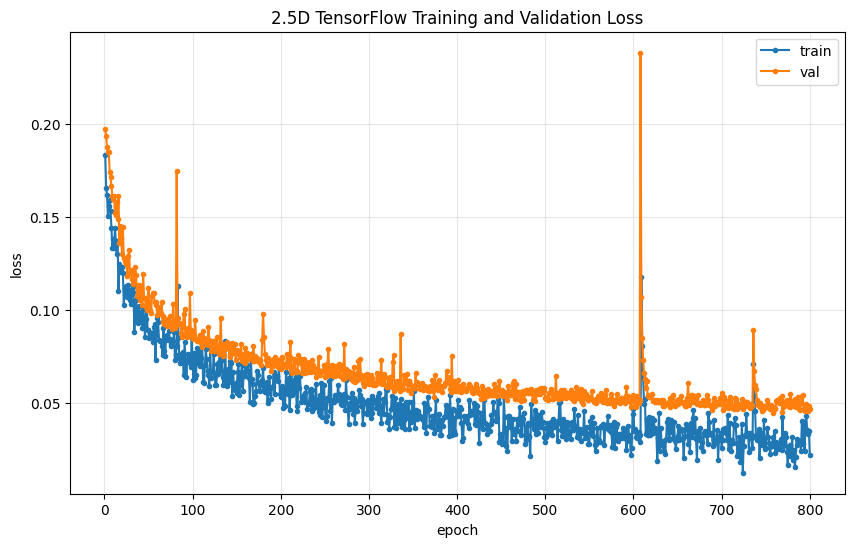

In [9]:
epochs_ran = np.arange(1, len(train_history) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs_ran, train_history, '.-', label='train')
plt.plot(epochs_ran, val_history,   '.-', label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('2.5D TensorFlow Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
